# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## frank2d

In [7]:
N = 100

In [8]:
frank2d = Frank2D(N, rout, geom)

In [9]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [10]:
u_gridded, v_gridded = frank2d.gridded_data['u'], frank2d.gridded_data['v']
q_gridded = np.hypot(u_gridded, v_gridded)
print(np.sort(q_gridded)/1e4)
print(q_gridded.min(), q_gridded.max())

[  0.           5.15662016   5.15662016 ... 361.00024205 361.00024205
 364.62810804]
0.0 3646281.0804362795


In [11]:
params_0 = {'m' : -1.995082249593998, 'c' : 8501943831.276791, 'l' : 1e3}
params_1 = {'m' : -1.995082249593998, 'c' : 8501943831.276791, 'l' : 1e4}
params_2 = {'m' : -1.995082249593998, 'c' : 8501943831.276791, 'l' : 7e4}
params_3 = {'m' : -1.995082249593998, 'c' : 8501943831.276791, 'l' : 9e4}
params_4 = {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 2e5}
params_5 = {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 5e5}

In [12]:
params = [params_0, params_1, params_2, params_3, params_4, params_5]

### Study first the kernels

In [13]:
param = params_4

In [80]:
tick_positions_y = [0, 700,1000,  3995]
tick_labels_y = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N+1}$",
    r"$(u, v)_{N^{2}}$",
]

tick_positions_x = [0, 700,  3995]
tick_labels_x = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N^{2}}$",
]

### SE Kernel

In [21]:
def factorSE(params):
    m = params['m']
    c = params['c']
    q1 = np.hypot(u1, v1)
    q2 = np.hypot(u2, v2)
    min_freq = np.sort(np.abs(np.unique(v)))[1]

    def power_spectrum(q, m, c):
        q[q == 0] = min_freq
        return (q**m)* c

    p1 = power_spectrum(q1, m, c)
    p2 = power_spectrum(q2, m, c)
    
    factor = np.sqrt(p1 * p2)
    return factor


In [22]:
u, v = frank2d.FT.uv_points_unshifted
u1, u2 = np.meshgrid(u, u)
v1, v2 = np.meshgrid(v, v)

In [23]:
def SE(params): 
    l = params['l']
    SE_Kernel = np.exp(-0.5*((u1-u2)**2 + (v1-v2)**2)/ l**2)
    return SE_Kernel

In [24]:
factor = factorSE(param)

In [41]:
matrixSE = SE(param) * factor

In [42]:
np.max(matrixSE)

3.372579402773245

In [43]:
np.array_equal(matrixSE, matrixSE.T)

True

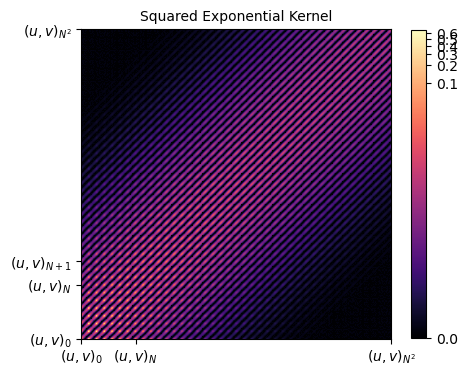

In [81]:
from matplotlib.colors import PowerNorm, SymLogNorm

plt.figure(figsize=(5,5))
plt.imshow( matrixSE, origin='lower',
            cmap =  'magma', norm=PowerNorm(gamma = 0.1,
            vmin=matrixSE.min(), vmax=matrixSE.max()/5))
plt.colorbar(shrink=0.8)
plt.xlim(0, 4000)
plt.ylim(0, 4000)
plt.xticks(tick_positions_x, tick_labels_x)
plt.yticks(tick_positions_y, tick_labels_y)
plt.title(r'Squared Exponential Kernel', size = 10)
plt.show()

### Wendland

In [38]:
def P_k(r, k):
    if k == 0:
        return np.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3
    else:
        raise ValueError("k must be 0, 1, or 2.")

def Wendland(l):
    j = 4
    k = 1
    H = 2*1.897367*l
    r = np.sqrt(((u1-u2)/H)**2 + ((v1-v2)/H)**2)
    r_normalized = r
    factor = (1 - r_normalized)**j
    factor[r_normalized > 1] = 0
    return   factor * P_k(r_normalized, k)

In [45]:
matrixW = Wendland(param['l'])*factor

In [59]:
np.array_equal(matrixW, matrixW.T)

True

<Figure size 640x480 with 0 Axes>

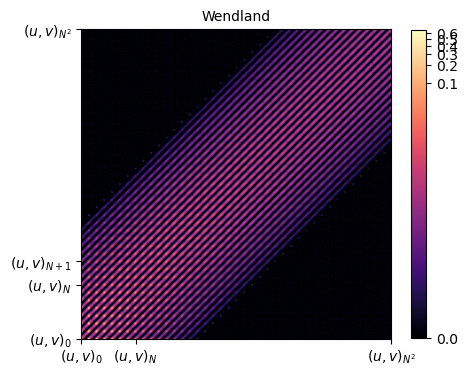

In [82]:
plt.clf()
plt.figure(figsize=(5,5))
plt.imshow( matrixW, origin='lower',
            cmap =  'magma', norm=PowerNorm(gamma = 0.1,
            vmin=matrixSE.min(), vmax=matrixSE.max()/5))
plt.xticks(tick_positions_x, tick_labels_x)
plt.yticks(tick_positions_y, tick_labels_y)
plt.colorbar(shrink=0.8)
plt.xlim(0, 4000)
plt.ylim(0, 4000)
plt.title(r'Wendland', size = 10)
plt.show()

<Figure size 640x480 with 0 Axes>

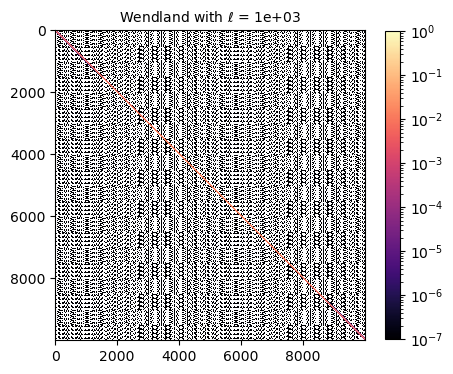

<Figure size 640x480 with 0 Axes>

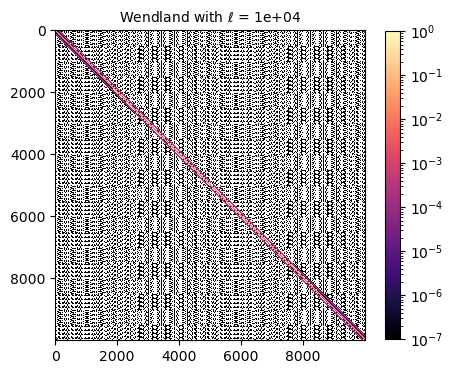

<Figure size 640x480 with 0 Axes>

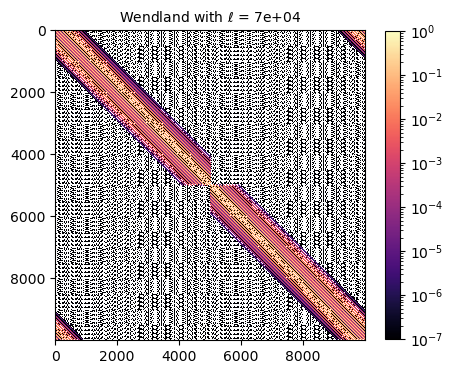

<Figure size 640x480 with 0 Axes>

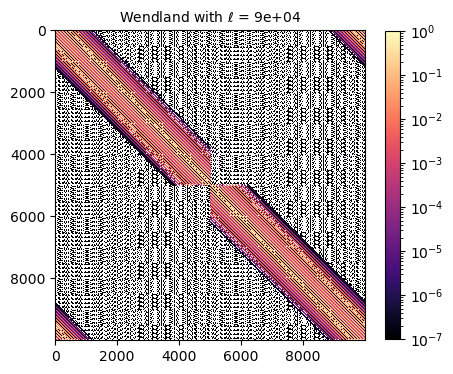

<Figure size 640x480 with 0 Axes>

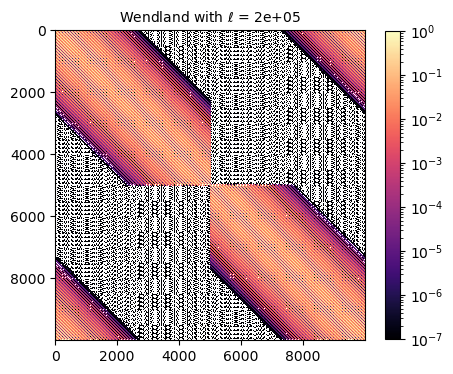

<Figure size 640x480 with 0 Axes>

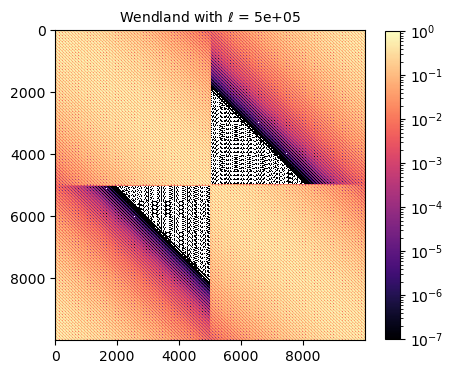

In [183]:
for param in params:
    matrixW = Wendland(param['l'])
    plt.clf()
    plt.figure(figsize=(5,5))
    plt.imshow(matrixW, cmap =  'magma', norm=LogNorm(vmin=1e-7, vmax=1))
    plt.colorbar(shrink=0.8)
    plt.title(r'Wendland with $\ell$ = ' + f'{param['l']:.0e} ', size = 10)
    plt.show()
    

## Frank for differents $\ell$

In [198]:
N = 300

In [199]:
frank2d_objects = []
times = []

===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 1000.0}
===>  Creating sparse linear system...
    + time kernel = 0.01  min |  0.80 seconds
Using preconditioner method:  jacobi
    + time building system = 0.01  min |  0.80 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.2212677737961322
     + final tolerance :  1.2212677737961322
                       .... iteration:  0
                        -> actual tol:  122126777.37961322  vs  1.2212677737961322
converged by norm of s


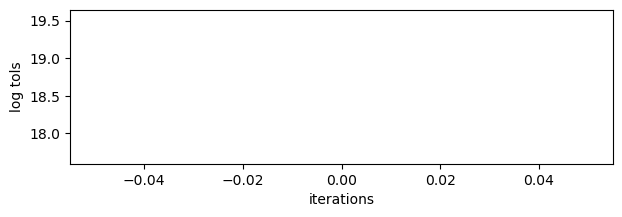

    + time = 0.00  min |  0.08 seconds
     + CGM converged?   True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.03  min |  1.69 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =1000.0 took 8.526301383972168 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 10000.0}
===>  Creating sparse linear system...
    + time kernel = 0.01  min |  0.80 seconds
Using preconditioner method:  jacobi
    + time building system = 0.01  min |  0.80 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.2212677737961322
     + final tolerance :  1.2212677737961322
                       .... iteration:  0
                        -> actual tol:  122126777.37961322  vs  1.2212677737961322
converged by nor

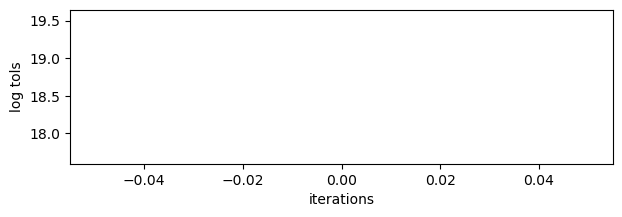

    + time = 0.00  min |  0.06 seconds
     + CGM converged?   True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.03  min |  1.66 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =10000.0 took 8.460458993911743 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 70000.0}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  2.06 seconds
Using preconditioner method:  jacobi
    + time building system = 0.04  min |  2.12 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.2212677737961322
     + final tolerance :  1.2212677737961322
                       .... iteration:  0
                        -> actual tol:  122126777.37961322  vs  1.2212677737961322
               

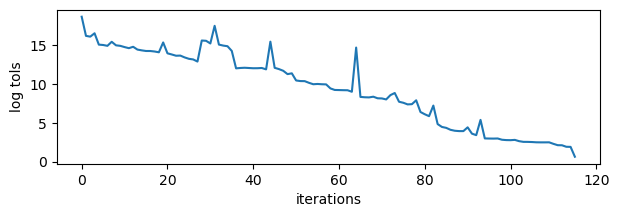

    + time = 0.05  min |  3.14 seconds
     + CGM converged?   True
         ✘✘✘✘✘✘ CGM Failed..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.06  min |  3.37 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =70000.0 took 14.611228704452515 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 90000.0}
===>  Creating sparse linear system...
    + time kernel = 0.04  min |  2.60 seconds
Using preconditioner method:  jacobi
    + time building system = 0.04  min |  2.70 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.2212677737961322
     + final tolerance :  1.2212677737961322
                       .... iteration:  0
                        -> actual tol:  122126777.37961322  vs  1.2212677737961322
               

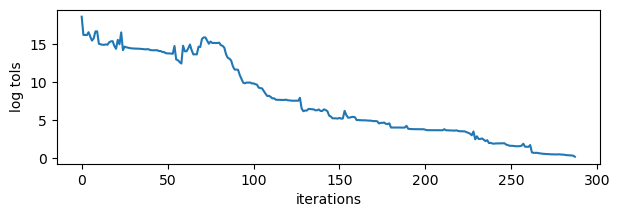

    + time = 0.21  min |  12.76 seconds
     + CGM converged?   True
         ✘✘✘✘✘✘ CGM Failed..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.07  min |  4.18 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =90000.0 took 25.63612389564514 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 200000.0}
===>  Creating sparse linear system...
    + time kernel = 0.14  min |  8.68 seconds
Using preconditioner method:  jacobi
    + time building system = 0.15  min |  9.12 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.2212677737961322
     + final tolerance :  1.2212677737961322
                       .... iteration:  0
                        -> actual tol:  122126777.37961322  vs  1.2212677737961322
              

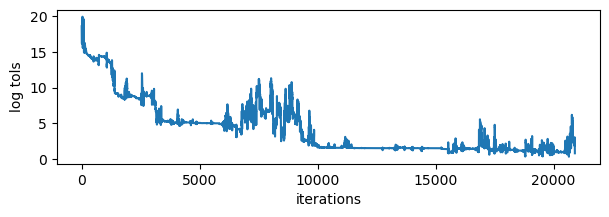

    + time = 70.25  min |  4214.77 seconds
     + CGM converged?   True
         ✘✘✘✘✘✘ CGM Failed..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.22  min |  12.97 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =200000.0 took 4242.903007984161 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 500000.0}
===>  Creating sparse linear system...


In [201]:
for i in range(len(params)):
    start = time.time()
    frank2d = Frank2D(N, rout, geom)
    frank2d.fit(data = uvtable, kernel_params = params[i], rtol = 1e-8)
    l_i = params[i]['l']

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l ={l_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)